# Peramalan Harga Saham INDF - Model Tunggal CNN
**Model tunggal CNN (tanpa BiLSTM) untuk perbandingan dengan Hybrid CNN-BiLSTM**

Grid parameter:
- n_filters    : [16, 32, 64]
- dropout_rate : [0.1, 0.2, 0.3]
- batch_size   : [16, 32, 64]
- Total: 3 x 3 x 3 = 27 kombinasi x 3 skenario = 81 run


## CELL 1 — Pra-Pemrosesan Data

--- ANALISIS AWAL DATA MENTAH ---
Total Hari Kerja Seharusnya : 2609 hari
Total Data Tersedia         : 2415 hari
Jumlah Data Hilang          : 194 hari


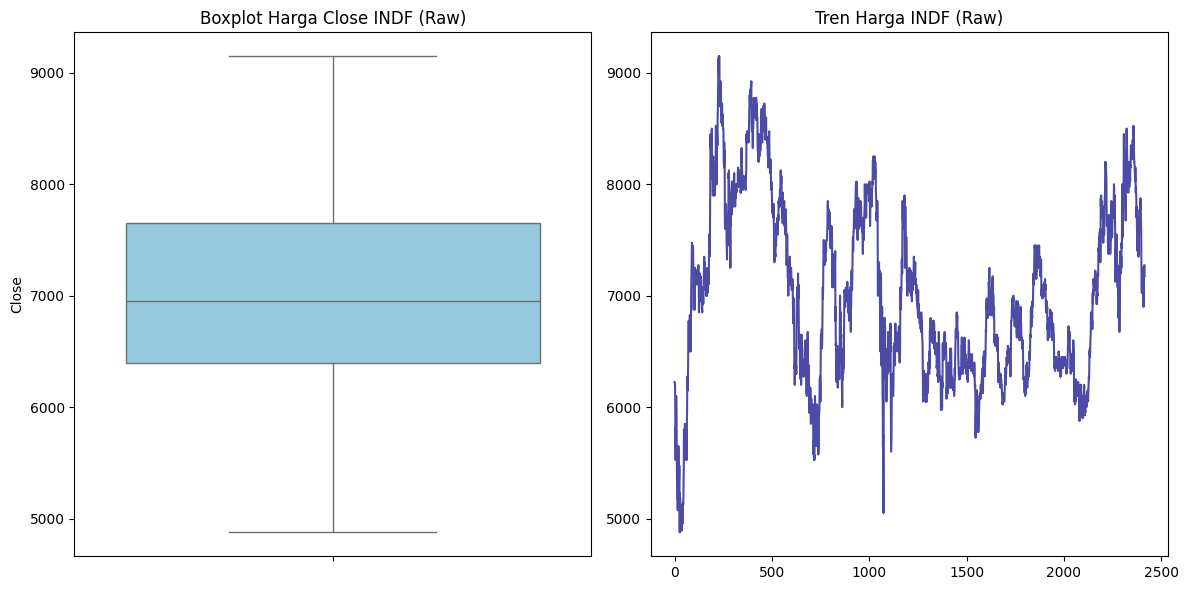


--- HASIL DETEKSI OUTLIER ---
Q1: 6400.0 | Q3: 7650.0 | IQR: 1250.0
Batas Bawah: 4525.0 | Batas Atas: 9525.0
Jumlah Outliers Terdeteksi: 0

✅ Tidak ditemukan outliers pada data mentah.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA & STANDARISASI KOLOM
df_raw = pd.read_csv('Data Historis INDF.csv', sep=';', thousands='.')
df = df_raw[['Tanggal', 'Terakhir']].rename(columns={'Tanggal': 'Date', 'Terakhir': 'Close'})

# 2. FORMAT TANGGAL & SORTIR
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date')
df = df.drop_duplicates(subset=['Date'], keep='first')

# 3. IDENTIFIKASI MISSING VALUES (Business Days)
all_business_days = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='B')
missing_dates = all_business_days.difference(df['Date'])

print(f"--- ANALISIS AWAL DATA MENTAH ---")
print(f"Total Hari Kerja Seharusnya : {len(all_business_days)} hari")
print(f"Total Data Tersedia         : {len(df)} hari")
print(f"Jumlah Data Hilang          : {len(missing_dates)} hari")

# 4. DETEKSI OUTLIERS
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(y=df['Close'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot Harga Close INDF (Raw)')
axes[1].plot(df.index, df['Close'], color='navy', alpha=0.7)
axes[1].set_title('Tren Harga INDF (Raw)')
plt.tight_layout()
plt.show()

Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]

print(f"\n--- HASIL DETEKSI OUTLIER ---")
print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Batas Bawah: {lower_bound} | Batas Atas: {upper_bound}")
print(f"Jumlah Outliers Terdeteksi: {len(outliers)}")
if len(outliers) > 0:
    print("\nDaftar Tanggal Outliers:")
    print(outliers)
else:
    print("\n✅ Tidak ditemukan outliers pada data mentah.")

|| MEMBUAT LIST TANGGAL YANG HILANG / MISSING VALUE ||

In [4]:
import pandas as pd

# 1. Load data mentah
df_raw = pd.read_csv('Data Historis INDF.csv', sep=';', thousands='.')
df_raw['Tanggal'] = pd.to_datetime(df_raw['Tanggal'], format='%d/%m/%Y')
df_raw = df_raw.sort_values('Tanggal')

# 2. Buat rentang hari kerja (Senin-Jumat) dari tanggal awal sampai akhir
full_range = pd.date_range(start=df_raw['Tanggal'].min(), end=df_raw['Tanggal'].max(), freq='B')

# 3. Cari tanggal yang ada di kalender hari kerja tapi tidak ada di dataset
missing_dates = full_range.difference(df_raw['Tanggal'])

# 4. Tampilkan hasil dalam bentuk tabel
missing_dates_df = pd.DataFrame(missing_dates, columns=['Tanggal_Kosong'])
missing_dates_df['Hari'] = missing_dates_df['Tanggal_Kosong'].dt.day_name() # Nama hari dalam Bahasa Inggris

print(f"Total Tanggal yang Hilang: {len(missing_dates_df)} hari")
print("\n--- 20 Tanggal Pertama yang Kosong ---")
print(missing_dates_df.head(20))

# Simpan ke CSV jika Anda ingin melihat daftar lengkapnya (194 hari)
missing_dates_df.to_csv('daftar_tanggal_kosong.csv', index=False)

Total Tanggal yang Hilang: 194 hari

--- 20 Tanggal Pertama yang Kosong ---
   Tanggal_Kosong       Hari
0      2015-12-09  Wednesday
1      2015-12-24   Thursday
2      2015-12-25     Friday
3      2015-12-31   Thursday
4      2016-01-01     Friday
5      2016-02-08     Monday
6      2016-03-09  Wednesday
7      2016-03-25     Friday
8      2016-05-05   Thursday
9      2016-05-06     Friday
10     2016-07-04     Monday
11     2016-07-05    Tuesday
12     2016-07-06  Wednesday
13     2016-07-07   Thursday
14     2016-07-08     Friday
15     2016-08-17  Wednesday
16     2016-09-12     Monday
17     2016-12-12     Monday
18     2016-12-26     Monday
19     2017-01-02     Monday


In [5]:
from sklearn.preprocessing import MinMaxScaler

# 5. REINDEXING & INTERPOLASI
df_indexed = df.set_index('Date')
all_business_days = pd.date_range(start=df_indexed.index.min(), end=df_indexed.index.max(), freq='B')
df_complete = df_indexed.reindex(all_business_days)

# Interpolasi Polinomial Ordo 2
df_complete['Close'] = df_complete['Close'].interpolate(method='polynomial', order=2)
df_complete['Close'] = df_complete['Close'].ffill().bfill()

# 6. NORMALISASI
# Catatan: Normalisasi tetap digunakan meskipun univariate karena membantu
# kestabilan gradient descent pada deep learning (nilai input terbatas 0-1).
# Hasil prediksi akan di-inverse transform kembali ke satuan Rupiah.
scaler_global = MinMaxScaler(feature_range=(0, 1))
df_complete['Close_Scaled'] = scaler_global.fit_transform(df_complete[['Close']])

# Simpan hasil
df_final = df_complete.reset_index().rename(columns={'index': 'Date'})
df_final.to_csv('INDF_Cleaned.csv', index=False)

print(f"✅ Pra-pemrosesan Selesai!")
print(f"Total Baris Akhir : {len(df_final)}")
print(f"Rentang Tanggal   : {df_final['Date'].min()} s/d {df_final['Date'].max()}")
print(f"Data disimpan ke  : 'INDF_Cleaned.csv'")
print(df_final.head())

✅ Pra-pemrosesan Selesai!
Total Baris Akhir : 2609
Rentang Tanggal   : 2015-10-23 00:00:00 s/d 2025-10-22 00:00:00
Data disimpan ke  : 'INDF_Cleaned.csv'
        Date   Close  Close_Scaled
0 2015-10-23  6225.0      0.315789
1 2015-10-26  6225.0      0.315789
2 2015-10-27  6200.0      0.309942
3 2015-10-28  6075.0      0.280702
4 2015-10-29  5650.0      0.181287


## CELL 3 — Load Data & Fungsi Windowing

In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# Load data bersih
df = pd.read_csv('INDF_Cleaned.csv', parse_dates=['Date'], index_col='Date')
data_full = df[['Close']].values   # Gunakan harga asli (Rupiah)

# Parameter tetap
WINDOW_SIZE = 30

def create_window_dataset(dataset, lookback):
    """Membuat pasangan (X, y) dari data time series dengan sliding window."""
    X, y = [], []
    for i in range(lookback, len(dataset)):
        X.append(dataset[i-lookback:i])
        y.append(dataset[i])
    return np.array(X), np.array(y)

# ==========================================
# INTI: FUNGSI PEMBAGI SKENARIO
# ==========================================
def jalankan_skenario(ratio_train, ratio_val, ratio_test):
    """
    Membagi data, normalisasi, lalu windowing dari data gabungan
    agar konteks antar segmen (train→val→test) tetap terjaga.

    Alur:
      1. Split data mentah (Close) → train / val / test
      2. Fit scaler HANYA pada train → transform val & test
      3. Gabungkan kembali → window dari full scaled
      4. Potong window hasil menjadi 3 bagian sesuai proporsi
    """
    label = f"{int(ratio_train*100)}-{int(ratio_val*100)}-{int(ratio_test*100)}"
    print(f"\n>>> MEMPERSIAPKAN SKENARIO {label} ...")

    n       = len(data_full)
    n_train = int(ratio_train * n)
    n_val   = int(ratio_val   * n)
    n_test  = n - n_train - n_val

    # 1. Split data mentah
    train_raw = data_full[:n_train]
    val_raw   = data_full[n_train : n_train + n_val]
    test_raw  = data_full[n_train + n_val :]

    # 2. Normalisasi — fit HANYA pada train (cegah data leakage)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled   = scaler.transform(val_raw)
    test_scaled  = scaler.transform(test_raw)

    # 3. Gabungkan untuk windowing (konteks antar segmen terjaga)
    full_scaled = np.concatenate([train_scaled, val_scaled, test_scaled])
    X_all, y_all = create_window_dataset(full_scaled, WINDOW_SIZE)

    # 4. Potong kembali sesuai proporsi
    # Jumlah window yang "dimiliki" tiap segmen:
    #   - Train menghasilkan (n_train - WINDOW_SIZE) window
    #   - Val & Test masing-masing menghasilkan n_val dan n_test window
    #     (mereka "meminjam" WINDOW_SIZE terakhir dari segmen sebelumnya sebagai konteks)
    n_train_w = n_train - WINDOW_SIZE
    n_val_w   = n_val
    # n_test_w  = n_test (sisa)

    X_train = X_all[:n_train_w]
    y_train = y_all[:n_train_w]

    X_val   = X_all[n_train_w : n_train_w + n_val_w]
    y_val   = y_all[n_train_w : n_train_w + n_val_w]

    X_test  = X_all[n_train_w + n_val_w :]
    y_test  = y_all[n_train_w + n_val_w :]

    print(f"   Total data      : {n} baris")
    print(f"   Train (mentah)  : {n_train} | Val: {n_val} | Test: {n_test}")
    print(f"   Shape X_train   : {X_train.shape}")
    print(f"   Shape X_val     : {X_val.shape}")
    print(f"   Shape X_test    : {X_test.shape}")

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val'  : X_val,   'y_val'  : y_val,
        'X_test' : X_test,  'y_test' : y_test,
        'scaler' : scaler
    }

# ==========================================
# EKSEKUSI 3 SKENARIO
# ==========================================
# List skenario: (Train, Val, Test)
skenario_list = [
    (0.80, 0.10, 0.10),
    (0.70, 0.15, 0.15),
    (0.60, 0.20, 0.20)
]

# Dictionary untuk menyimpan semua data siap pakai
datasets = {}

for r_train, r_val, r_test in skenario_list:
    nama = f"{int(r_train*100)}-{int(r_val*100)}-{int(r_test*100)}"
    datasets[nama] = jalankan_skenario(r_train, r_val, r_test)

print("\n✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']")


>>> MEMPERSIAPKAN SKENARIO 80-10-10 ...
   Total data      : 2609 baris
   Train (mentah)  : 2087 | Val: 260 | Test: 262
   Shape X_train   : (2057, 30, 1)
   Shape X_val     : (260, 30, 1)
   Shape X_test    : (262, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 70-15-15 ...
   Total data      : 2609 baris
   Train (mentah)  : 1826 | Val: 391 | Test: 392
   Shape X_train   : (1796, 30, 1)
   Shape X_val     : (391, 30, 1)
   Shape X_test    : (392, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 60-20-20 ...
   Total data      : 2609 baris
   Train (mentah)  : 1565 | Val: 521 | Test: 523
   Shape X_train   : (1535, 30, 1)
   Shape X_val     : (521, 30, 1)
   Shape X_test    : (523, 30, 1)

✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']


## CELL 5 - Definisi Arsitektur Model CNN (Tunggal)


In [7]:
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D,
                                     Dense, Dropout, Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tf.random.set_seed(42)
np.random.seed(42)

def bangun_model(window_size, n_filters, dropout_rate):
    model = Sequential(name=f'CNN_f{n_filters}')
    model.add(Conv1D(filters=n_filters, kernel_size=3, activation='relu',
                     padding='same', input_shape=(window_size, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(dropout_rate))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def hitung_metrik(y_true_scaled, y_pred_scaled, scaler):
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

print('Fungsi model CNN tunggal siap digunakan.')


Fungsi model CNN tunggal siap digunakan.


## CELL 6 - Hyperparameter Tuning CNN (Grid Search)

Grid: n_filters [16,32,64] x dropout [0.1,0.2,0.3] x batch_size [16,32,64]
= 27 kombinasi x 3 skenario = 81 run


In [9]:
from itertools import product
import os

os.makedirs('models', exist_ok=True)

param_grid = {
    'n_filters'    : [16, 32, 64],
    'dropout_rate' : [0.1, 0.2, 0.3],
    'batch_size'   : [16, 32, 64],
}

EPOCHS   = 30
PATIENCE = 10
skenario_list = ['80-10-10', '70-15-15', '60-20-20']

kombinasi = list(product(
    param_grid['n_filters'],
    param_grid['dropout_rate'],
    param_grid['batch_size'],
))

total_kombi    = len(kombinasi)
total_skenario = len(skenario_list)
total_run      = total_kombi * total_skenario

print("=" * 70)
print("  HYPERPARAMETER TUNING CNN (TUNGGAL)")
print(f"  {total_kombi} kombinasi x {total_skenario} skenario = {total_run} total run")
print("=" * 70)

hasil_tuning = []

for nama_skenario in skenario_list:
    data    = datasets[nama_skenario]
    X_train = data['X_train']
    y_train = data['y_train']
    X_val   = data['X_val']
    y_val   = data['y_val']
    X_test  = data['X_test']
    y_test  = data['y_test']
    scaler  = data['scaler']

    print(f"\n>>> SKENARIO {nama_skenario}")
    print("-" * 70)

    for idx, (n_filters, dropout, batch_size) in enumerate(kombinasi, 1):
        nama = f"f{n_filters}_d{int(dropout*10)}_b{batch_size}"
        print(f"  [{idx:02d}/{total_kombi}] {nama} ...", end=' ')

        model = bangun_model(
            window_size  = WINDOW_SIZE,
            n_filters    = n_filters,
            dropout_rate = dropout
        )

        early_stop = EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=0
        )

        waktu_mulai = time.time()
        history = model.fit(
            X_train, y_train,
            epochs          = EPOCHS,
            batch_size      = batch_size,
            validation_data = (X_val, y_val),
            callbacks       = [early_stop],
            verbose         = 0
        )
        durasi_detik   = time.time() - waktu_mulai
        epoch_berhenti = len(history.history['loss'])

        y_pred = model.predict(X_test, verbose=0)
        mae, rmse, mape, r2 = hitung_metrik(y_test, y_pred, scaler)

        hasil_tuning.append({
            'Nama'          : nama,
            'Skenario'      : nama_skenario,
            'Filter CNN'    : n_filters,
            'Dropout'       : dropout,
            'Batch Size'    : batch_size,
            'Epoch Berhenti': epoch_berhenti,
            'Waktu (detik)' : round(durasi_detik, 2),
            'MAE'           : round(mae, 4),
            'RMSE'          : round(rmse, 4),
            'MAPE (%)'      : round(mape, 4),
            'R²'            : round(r2, 4)
        })

        print(f"Epoch: {epoch_berhenti} | Waktu: {durasi_detik:.2f} dtk | MAPE: {mape:.4f}% | R2: {r2:.4f}")

df_tuning = pd.DataFrame(hasil_tuning)
df_tuning.to_csv('hasil_tuning_CNN.csv', index=False)

print("\n" + "=" * 70)
print("  TOP 1 KONFIGURASI PER SKENARIO - CNN")
print("=" * 70)
top1_per_skenario = {}
for nama_skenario in skenario_list:
    subset = df_tuning[df_tuning['Skenario'] == nama_skenario]
    top1   = subset.loc[subset['MAPE (%)'].idxmin()]
    top1_per_skenario[nama_skenario] = top1
    print(f"  {nama_skenario} -> {top1['Nama']} | "
          f"MAE: {top1['MAE']} | RMSE: {top1['RMSE']} | MAPE: {top1['MAPE (%)']}%")

best_overall = df_tuning.loc[df_tuning['MAPE (%)'].idxmin()]
print("\n" + "=" * 70)
print("  KONFIGURASI TERBAIK KESELURUHAN - CNN")
print("=" * 70)
print(f"  Nama       : {best_overall['Nama']}")
print(f"  Skenario   : {best_overall['Skenario']}")
print(f"  Filter CNN : {int(best_overall['Filter CNN'])}")
print(f"  Dropout    : {best_overall['Dropout']}")
print(f"  Batch Size : {int(best_overall['Batch Size'])}")
print(f"  MAE        : {best_overall['MAE']}")
print(f"  RMSE       : {best_overall['RMSE']}")
print(f"  MAPE       : {best_overall['MAPE (%)']}%")
print("\nHasil tuning disimpan ke: 'hasil_tuning_CNN.csv'")


  HYPERPARAMETER TUNING CNN (TUNGGAL)
  27 kombinasi x 3 skenario = 81 total run

>>> SKENARIO 80-10-10
----------------------------------------------------------------------
  [01/27] f16_d1_b16 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 30 | Waktu: 15.54 dtk | MAPE: 1.6489% | R2: 0.7747
  [02/27] f16_d1_b32 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 30 | Waktu: 9.51 dtk | MAPE: 1.6340% | R2: 0.7775
  [03/27] f16_d1_b64 ... 

...

Epoch: 30 | Waktu: 12.35 dtk | MAPE: 1.3184% | R2: 0.9624
  [26/27] f64_d3_b32 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 25 | Waktu: 7.71 dtk | MAPE: 1.3091% | R2: 0.9626
  [27/27] f64_d3_b64 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 30 | Waktu: 6.39 dtk | MAPE: 1.3515% | R2: 0.9616

  TOP 1 KONFIGURASI PER SKENARIO - CNN
  80-10-10 -> f64_d1_b32 | MAE: 118.8632 | RMSE: 168.1516 | MAPE: 1.5528%
  70-15-15 -> f64_d1_b16 | MAE: 100.4945 | RMSE: 147.3661 | MAPE: 1.3629%
  60-20-20 -> f32_d1_b32 | MAE: 86.403 | RMSE: 128.4531 | MAPE: 1.1956%

  KONFIGURASI TERBAIK KESELURUHAN - CNN
  Nama       : f32_d1_b32
  Skenario   : 60-20-20
  Filter CNN : 32
  Dropout    : 0.1
  Batch Size : 32
  MAE        : 86.403
  RMSE       : 128.4531
  MAPE       : 1.1956%

Hasil tuning disimpan ke: 'hasil_tuning_CNN.csv'


## CELL 7 — Visualisasi Trade-Off Tuning

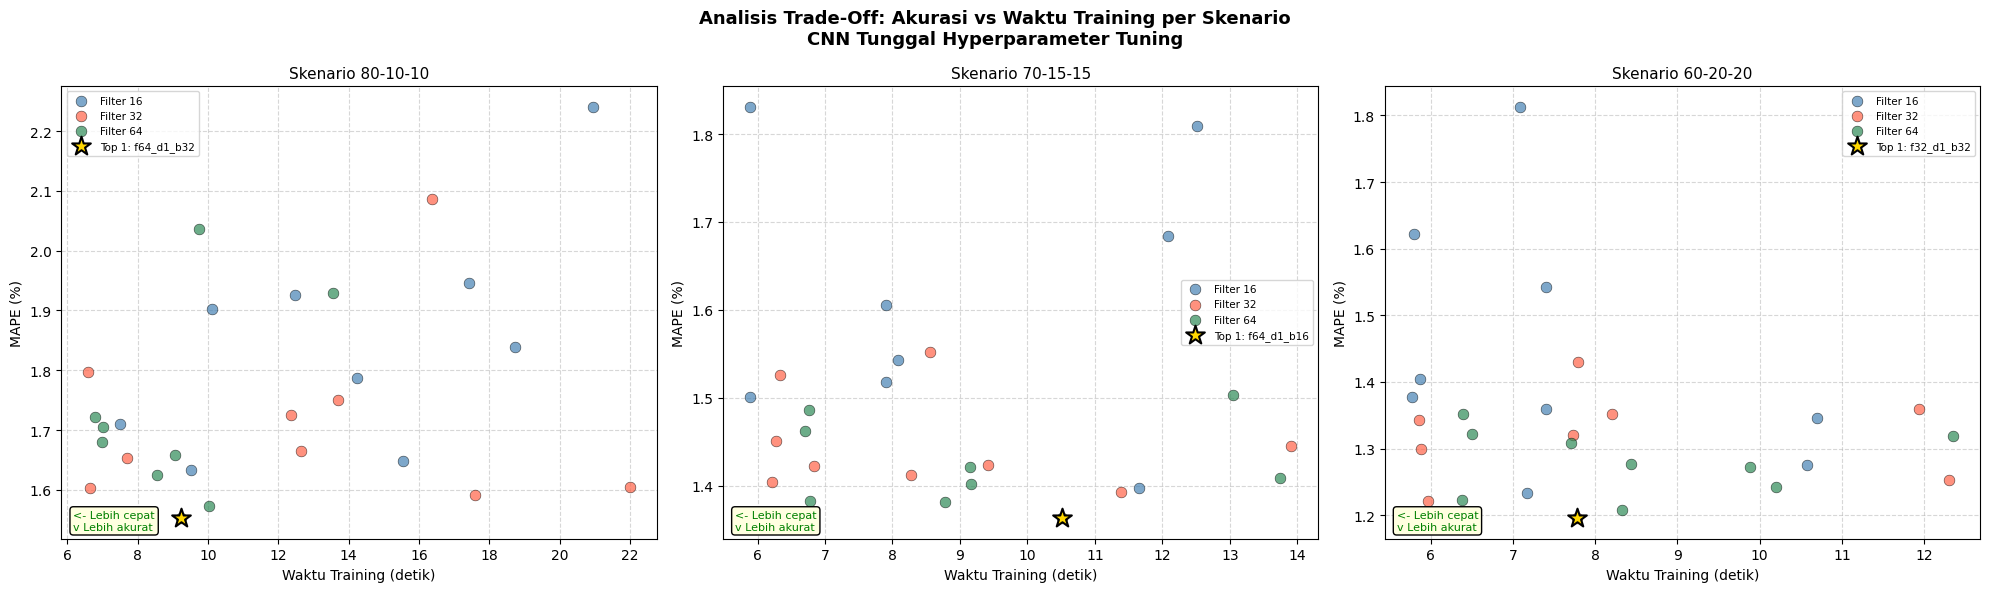

✅ Grafik trade-off disimpan ke: 'tradeoff_tuning_CNN.png'


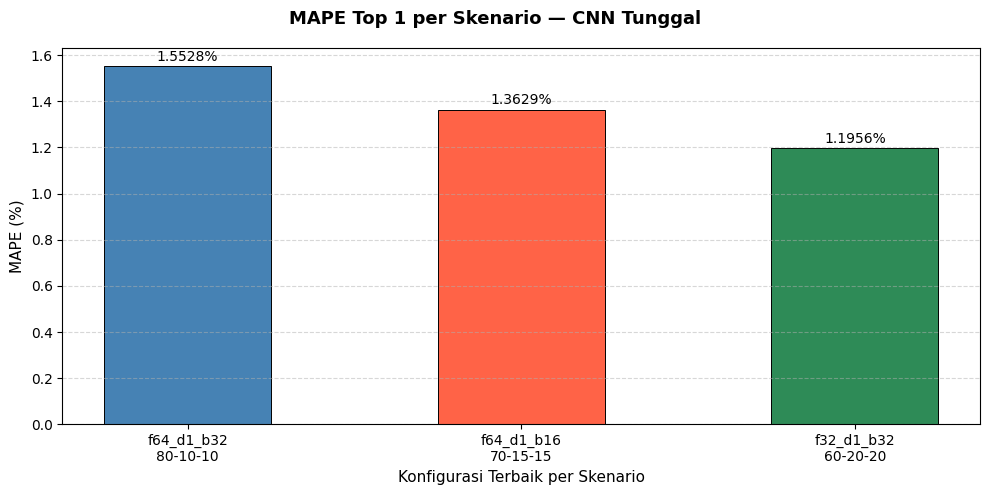

✅ Grafik top 1 per skenario disimpan ke: 'top1_per_skenario_CNN.png'


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Analisis Trade-Off: Akurasi vs Waktu Training per Skenario\n'
    'CNN Tunggal Hyperparameter Tuning',
    fontsize=13, fontweight='bold'
)

colors_filter = {16: 'steelblue', 32: 'tomato', 64: 'seagreen'}

for col_idx, nama_skenario in enumerate(skenario_list):
    ax     = axes[col_idx]
    subset = df_tuning[df_tuning['Skenario'] == nama_skenario]
    top1   = top1_per_skenario[nama_skenario]

    for n_filter in [16, 32, 64]:
        s = subset[subset['Filter CNN'] == n_filter]
        ax.scatter(
            s['Waktu (detik)'], s['MAPE (%)'],
            c=colors_filter[n_filter],
            label=f'Filter {n_filter}',
            s=60, edgecolors='black', linewidths=0.4, alpha=0.7, zorder=3
        )

    # Highlight top 1
    ax.scatter(
        [top1['Waktu (detik)']], [top1['MAPE (%)']],
        c='gold', s=200, edgecolors='black',
        linewidths=1.5, zorder=5, marker='*',
        label=f"Top 1: {top1['Nama']}"
    )

    ax.set_title(f'Skenario {nama_skenario}', fontsize=11)
    ax.set_xlabel('Waktu Training (detik)', fontsize=10)
    ax.set_ylabel('MAPE (%)', fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.annotate(
        '<- Lebih cepat\nv Lebih akurat',
        xy=(0.02, 0.02), xycoords='axes fraction',
        fontsize=8, color='green',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow')
    )

plt.tight_layout()
plt.savefig('tradeoff_tuning_CNN.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik trade-off disimpan ke: 'tradeoff_tuning_CNN.png'")

# Bar chart top 1 per skenario
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('MAPE Top 1 per Skenario — CNN Tunggal', fontsize=13, fontweight='bold')

nama_list = [top1_per_skenario[s]['Nama'] + '\n' + s for s in skenario_list]
mape_list = [top1_per_skenario[s]['MAPE (%)'] for s in skenario_list]
bars      = ax.bar(nama_list, mape_list, color=['steelblue', 'tomato', 'seagreen'],
                   edgecolor='black', linewidth=0.7, width=0.5)

for bar, val in zip(bars, mape_list):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('MAPE (%)', fontsize=11)
ax.set_xlabel('Konfigurasi Terbaik per Skenario', fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('top1_per_skenario_CNN.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik top 1 per skenario disimpan ke: 'top1_per_skenario_CNN.png'")

## CELL 8 - Training Final CNN: 1 Konfigurasi Terbaik x 3 Skenario


In [12]:
best_overall = df_tuning.loc[df_tuning['MAPE (%)'].idxmin()]

konfigurasi_terbaik = {
    'nama'        : best_overall['Nama'],
    'n_filters'   : int(best_overall['Filter CNN']),
    'dropout_rate': float(best_overall['Dropout']),
    'batch_size'  : int(best_overall['Batch Size']),
}

skenario_final = ['80-10-10', '70-15-15', '60-20-20']
EPOCHS_FINAL   = 30
PATIENCE_FINAL = 10

hasil_final   = []
history_final = {}
model_final   = {}

print('=' * 70)
print('  TRAINING FINAL CNN (TUNGGAL)')
print(f"  Konfigurasi: {konfigurasi_terbaik['nama']}")
print('=' * 70)

for nama_skenario in skenario_final:
    key  = f"{konfigurasi_terbaik['nama']}_{nama_skenario}"
    data = datasets[nama_skenario]
    print(f'\n>>> [{key}]')

    model = bangun_model(
        window_size  = WINDOW_SIZE,
        n_filters    = konfigurasi_terbaik['n_filters'],
        dropout_rate = konfigurasi_terbaik['dropout_rate'],
    )

    early_stop = EarlyStopping(
        monitor='val_loss', patience=PATIENCE_FINAL,
        restore_best_weights=True, verbose=0
    )
    checkpoint = ModelCheckpoint(
        filepath=f"models/{key}_CNN.keras",
        monitor='val_loss', save_best_only=True, verbose=0
    )

    waktu_mulai = time.time()
    history = model.fit(
        data['X_train'], data['y_train'],
        epochs          = EPOCHS_FINAL,
        batch_size      = konfigurasi_terbaik['batch_size'],
        validation_data = (data['X_val'], data['y_val']),
        callbacks       = [early_stop, checkpoint],
        verbose         = 0
    )
    durasi_detik   = time.time() - waktu_mulai
    epoch_berhenti = len(history.history['loss'])

    y_pred = model.predict(data['X_test'], verbose=0)
    mae, rmse, mape, r2 = hitung_metrik(data['y_test'], y_pred, data['scaler'])

    hasil_final.append({
        'Konfigurasi'   : konfigurasi_terbaik['nama'],
        'Skenario'      : nama_skenario,
        'Epoch Berhenti': epoch_berhenti,
        'Waktu (detik)' : round(durasi_detik, 2),
        'MAE'           : round(mae, 4),
        'RMSE'          : round(rmse, 4),
        'MAPE (%)'      : round(mape, 4),
        'R2'            : round(r2, 4),
    })

    history_final[key] = history.history
    model_final[key]   = model

    print(f'    Epoch: {epoch_berhenti} | Waktu: {durasi_detik:.2f} dtk | '
          f'MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4f}% | R2: {r2:.4f}')

df_final_hasil = pd.DataFrame(hasil_final)
df_final_hasil.to_csv('hasil_training_final_CNN.csv', index=False)

print('\n' + '=' * 70)
print('  REKAP HASIL TRAINING FINAL CNN')
print('=' * 70)
print(df_final_hasil.to_string(index=False))

best_idx      = df_final_hasil['MAPE (%)'].idxmin()
best_row      = df_final_hasil.loc[best_idx]
best_skenario = best_row['Skenario']
best_key      = f"{konfigurasi_terbaik['nama']}_{best_skenario}"
best_mape     = best_row['MAPE (%)']
best_mae      = best_row['MAE']
best_rmse     = best_row['RMSE']
best_r2       = best_row['R2']
best_label    = f"CNN ({konfigurasi_terbaik['nama']})"

print(f'\nModel terbaik CNN: {best_key} | MAPE: {best_mape}% | R2: {best_r2}')


  TRAINING FINAL CNN (TUNGGAL)
  Konfigurasi: f32_d1_b32

>>> [f32_d1_b32_80-10-10]


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    Epoch: 30 | Waktu: 18.07 dtk | MAE: 118.75 | RMSE: 166.56 | MAPE: 1.5484% | R2: 0.8100

>>> [f32_d1_b32_70-15-15]


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    Epoch: 30 | Waktu: 17.47 dtk | MAE: 102.61 | RMSE: 148.80 | MAPE: 1.3915% | R2: 0.9585

>>> [f32_d1_b32_60-20-20]


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    Epoch: 25 | Waktu: 19.30 dtk | MAE: 94.94 | RMSE: 144.27 | MAPE: 1.3047% | R2: 0.9617

  REKAP HASIL TRAINING FINAL CNN
Konfigurasi Skenario  Epoch Berhenti  Waktu (detik)      MAE     RMSE  MAPE (%)     R2
 f32_d1_b32 80-10-10              30          18.07 118.7533 166.5584    1.5484 0.8100
 f32_d1_b32 70-15-15              30          17.47 102.6052 148.7957    1.3915 0.9585
 f32_d1_b32 60-20-20              25          19.30  94.9353 144.2727    1.3047 0.9617

Model terbaik CNN: f32_d1_b32_60-20-20 | MAPE: 1.3047% | R2: 0.9617


## CELL 9 — Loss Curve (Training vs Validation)

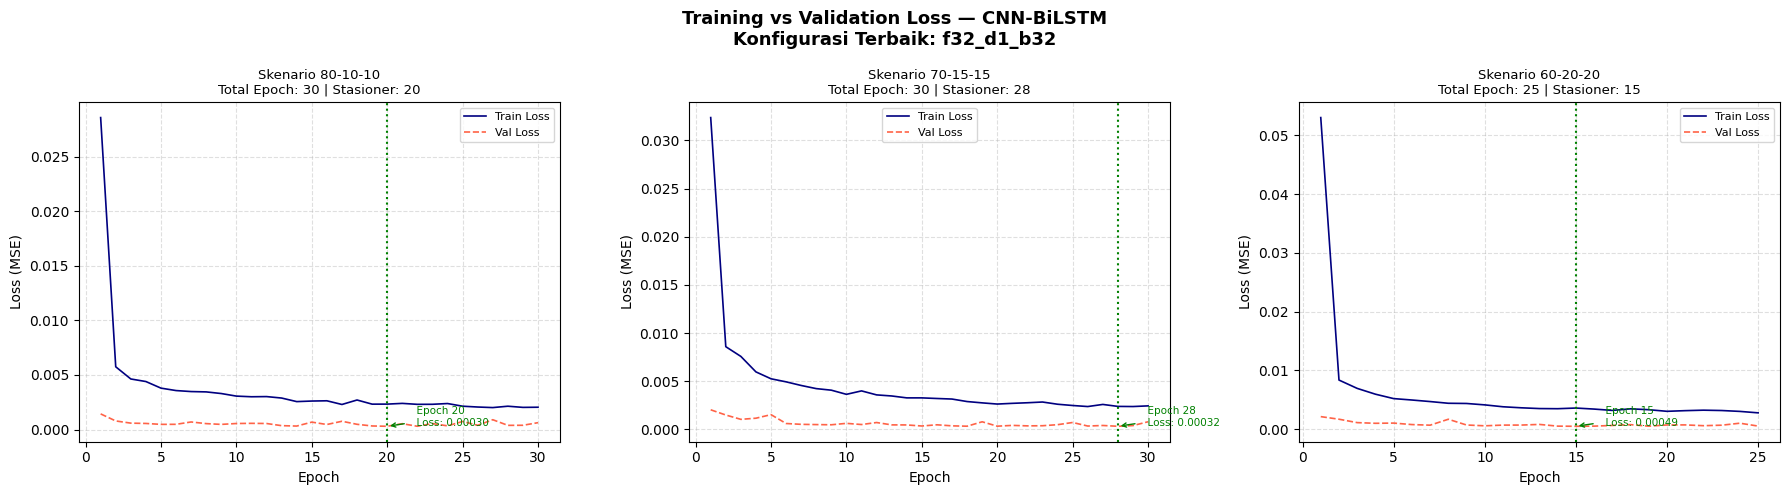

✅ Loss curve disimpan ke: 'loss_curve.png'


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Training vs Validation Loss — CNN Tunggal\n'
    f'Konfigurasi Terbaik: {konfigurasi_terbaik["nama"]}',
    fontsize=13, fontweight='bold'
)

for col_idx, nama_skenario in enumerate(skenario_final):
    key = f"{konfigurasi_terbaik['nama']}_{nama_skenario}"
    ax  = axes[col_idx]
    h   = history_final[key]

    total_epoch   = len(h['loss'])
    val_loss_arr  = np.array(h['val_loss'])
    best_epoch    = int(np.argmin(val_loss_arr)) + 1
    best_val_loss = val_loss_arr[best_epoch - 1]

    ax.plot(range(1, total_epoch + 1), h['loss'],
            label='Train Loss', color='navy', linewidth=1.2)
    ax.plot(range(1, total_epoch + 1), h['val_loss'],
            label='Val Loss', color='tomato',
            linewidth=1.2, linestyle='--')

    ax.axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5)
    ax.annotate(
        f'  Epoch {best_epoch}\n  Loss: {best_val_loss:.5f}',
        xy=(best_epoch, best_val_loss),
        xytext=(best_epoch + total_epoch * 0.05, best_val_loss * 1.15),
        fontsize=7.5, color='green',
        arrowprops=dict(arrowstyle='->', color='green', lw=1)
    )

    ax.set_title(
        f'Skenario {nama_skenario}\n'
        f'Total Epoch: {total_epoch} | Stasioner: {best_epoch}',
        fontsize=9.5
    )
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('loss_curve_CNN.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Loss curve disimpan ke: 'loss_curve_CNN.png'")


## CELL 10 — Perbandingan Metrik Evaluasi (Bar Chart)

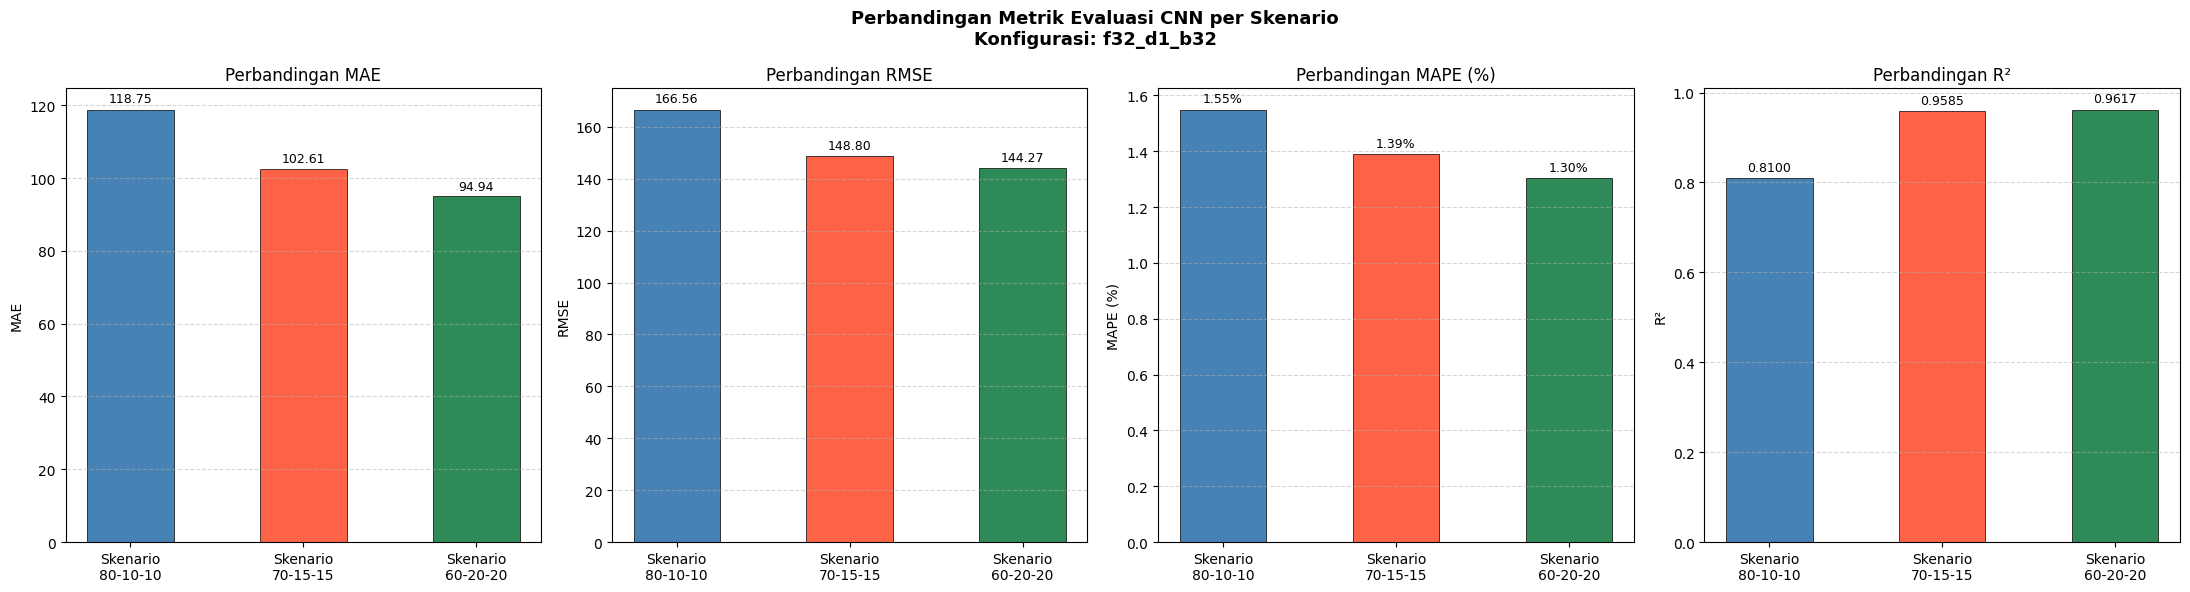


Performa terbaik CNN:
   Skenario : 60-20-20
   MAE      : 94.94
   RMSE     : 144.27
   MAPE     : 1.3047%
   R²       : 0.9617


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle(
    f'Perbandingan Metrik Evaluasi CNN per Skenario\n'
    f'Konfigurasi: {konfigurasi_terbaik["nama"]}',
    fontsize=13, fontweight='bold'
)

metrik_list  = ['MAE', 'RMSE', 'MAPE (%)', 'R2']
metrik_label = ['MAE', 'RMSE', 'MAPE (%)', 'R²']
bar_colors   = ['steelblue', 'tomato', 'seagreen']

for i, (metrik, label) in enumerate(zip(metrik_list, metrik_label)):
    ax   = axes[i]
    vals = df_final_hasil[metrik].values

    bars = ax.bar(
        [f'Skenario\n{s}' for s in skenario_final],
        vals, color=bar_colors,
        edgecolor='black', linewidth=0.5, width=0.5
    )

    for bar, val in zip(bars, vals):
        if metrik == 'MAPE (%)':
            txt = f'{val:.2f}%'
        elif metrik == 'R2':
            txt = f'{val:.4f}'
        else:
            txt = f'{val:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.01 * val,
                txt, ha='center', va='bottom', fontsize=9)

    ax.set_ylabel(label)
    ax.set_title(f'Perbandingan {label}')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('evaluasi_perbandingan_CNN.png', dpi=150, bbox_inches='tight')
plt.show()

best_row = df_final_hasil.loc[df_final_hasil['MAPE (%)'].idxmin()]
print(f'\nPerforma terbaik CNN:')
print(f"   Skenario : {best_row['Skenario']}")
print(f"   MAE      : {best_row['MAE']:.2f}")
print(f"   RMSE     : {best_row['RMSE']:.2f}")
print(f"   MAPE     : {best_row['MAPE (%)']}%")
print(f"   R²       : {best_row['R2']:.4f}")


## CELL 11 — Visualisasi Prediksi vs Aktual (1 Grafik Terbaik)

**Revisi:** Hanya menampilkan 1 grafik dari model dengan MAPE terkecil,
bukan semua 6 kombinasi.

Model terbaik: f32_d1_b32_60-20-20
MAE: 94.94 | RMSE: 144.27 | MAPE: 1.3047% | R2: 0.9617


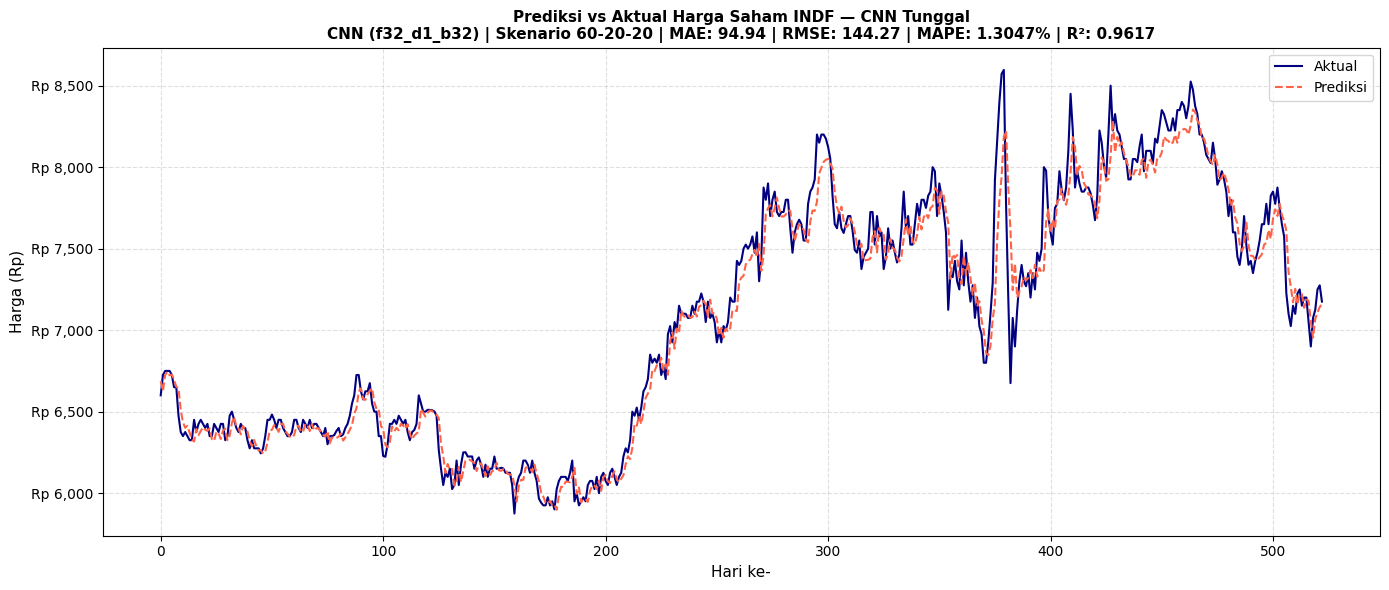

Grafik prediksi disimpan ke: prediksi_vs_aktual_terbaik_CNN.png


In [15]:
best_idx      = df_final_hasil['MAPE (%)'].idxmin()
best_row      = df_final_hasil.loc[best_idx]
best_key      = f"{best_row['Konfigurasi']}_{best_row['Skenario']}"
best_skenario = best_row['Skenario']
best_label    = f"CNN ({best_row['Konfigurasi']})"
best_mape     = best_row['MAPE (%)']
best_mae      = best_row['MAE']
best_rmse     = best_row['RMSE']
best_r2       = best_row['R2']

print(f'Model terbaik: {best_key}')
print(f'MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}% | R2: {best_r2:.4f}')

data = datasets[best_skenario]

y_pred_scaled = model_final[best_key].predict(data['X_test'], verbose=0)

y_true = data['scaler'].inverse_transform(data['y_test'].reshape(-1, 1)).flatten()
y_pred = data['scaler'].inverse_transform(y_pred_scaled).flatten()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_true, label='Aktual', color='navy', linewidth=1.5)
ax.plot(y_pred, label='Prediksi', color='tomato', linewidth=1.5, linestyle='--')

ax.set_title(
    f'Prediksi vs Aktual Harga Saham INDF — CNN Tunggal\n'
    f'{best_label} | Skenario {best_skenario} | '
    f'MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}% | R²: {best_r2:.4f}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Hari ke-', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))

plt.tight_layout()
plt.savefig('prediksi_vs_aktual_terbaik_CNN.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik prediksi disimpan ke: prediksi_vs_aktual_terbaik_CNN.png')


## CELL 13 — Prediksi 1 Hari & 30 Hari ke Depan

Kedua prediksi dijalankan dalam 1 cell menggunakan strategi **recursive forecasting**:
- Loop 30 iterasi, iterasi pertama = prediksi 1 hari (23 Oktober 2025)
- Setiap hasil prediksi dianggap aktual dan dimasukkan ke window berikutnya
- Output: prediksi 1 hari + tabel & grafik prediksi 30 hari


  PREDIKSI HARGA SAHAM INDF — 1 HARI KE DEPAN
  Model            : f32_d1_b32_60-20-20
  Data terakhir    : 22 October 2025 | Harga: Rp 7,175
  Tanggal prediksi : 23 October 2025
  Prediksi Harga   : Rp 7,079.37
  Selisih          : Rp 95.63 (turun)

  PREDIKSI HARGA SAHAM INDF — 30 HARI KE DEPAN
  Model    : f32_d1_b32_60-20-20
  Strategi : Recursive Forecasting
  Mulai    : 23 October 2025
  Selesai  : 03 December 2025
         Tanggal  Prediksi (Rp)
 23 October 2025    7079.370117
 24 October 2025    7057.049805
 27 October 2025    7048.680176
 28 October 2025    7057.410156
 29 October 2025    7057.020020
 30 October 2025    7049.819824
 31 October 2025    7042.439941
03 November 2025    7014.189941
04 November 2025    6988.819824
05 November 2025    6960.089844
06 November 2025    6946.049805
07 November 2025    6928.799805
10 November 2025    6914.500000
11 November 2025    6905.930176
12 November 2025    6904.220215
13 November 2025    6893.669922
14 November 2025    6865.459961

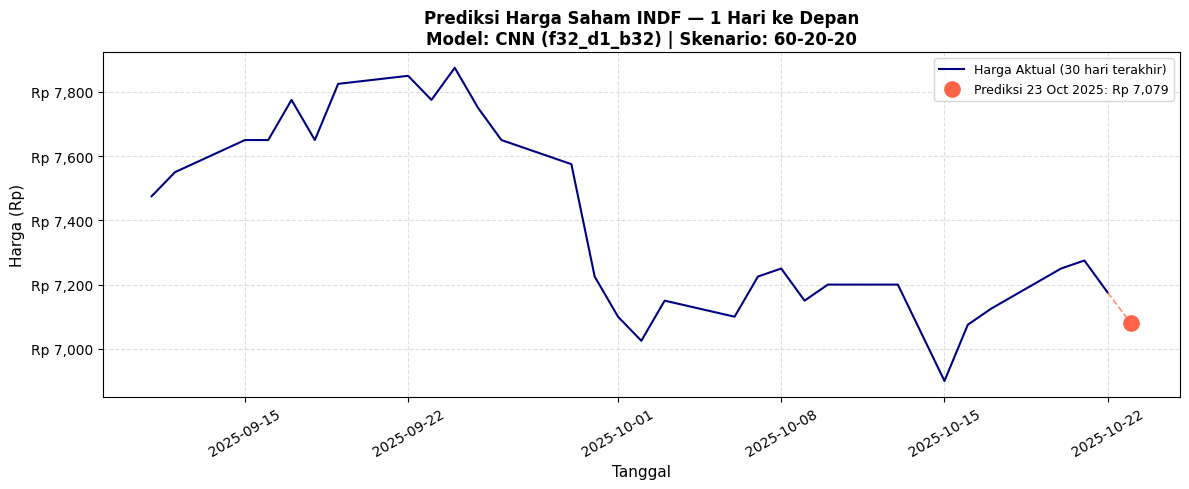

✅ Grafik prediksi 1 hari disimpan ke: 'prediksi_1hari_CNN.png'


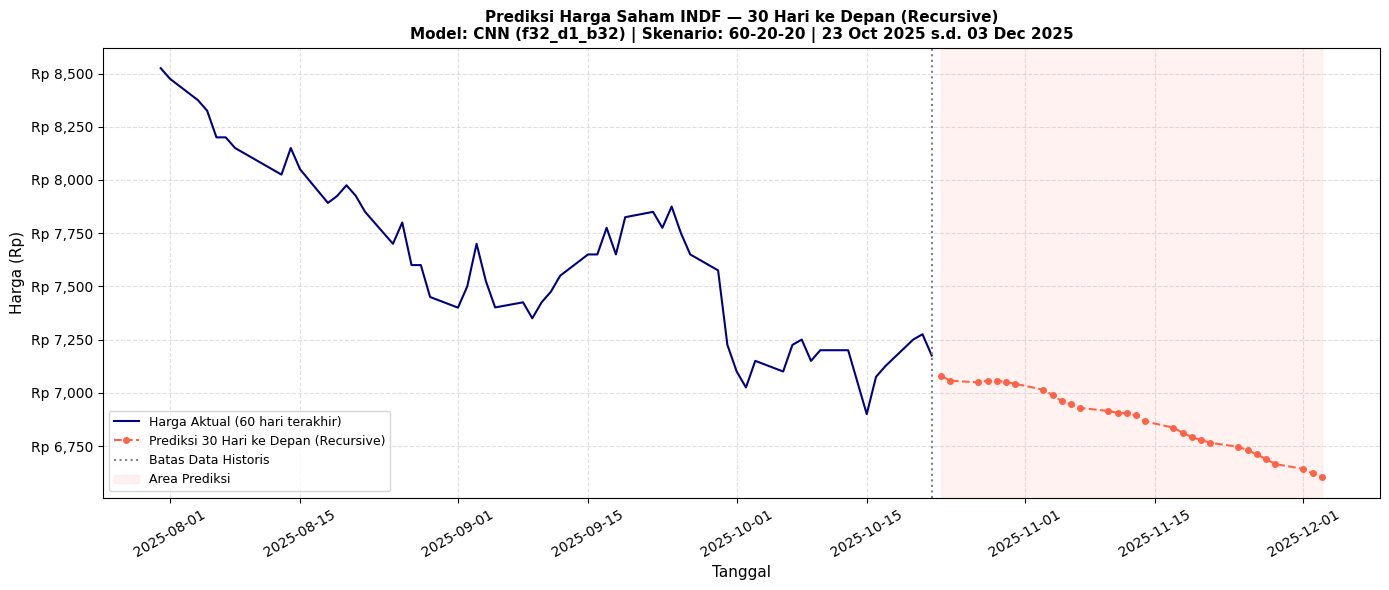

✅ Grafik prediksi 30 hari disimpan ke: 'prediksi_30hari_CNN.png'


In [18]:
# ============================================================
# CELL 13 — PREDIKSI 1 HARI & 30 HARI KE DEPAN (RECURSIVE)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DAYS_AHEAD = 30

# ── Definisi variabel yang dibutuhkan ──
model_terbaik      = model_final[best_key]
scaler_terbaik     = datasets[best_skenario]['scaler']
data_close_full    = df[['Close']].values
last_window_raw    = data_close_full[-WINDOW_SIZE:]
last_window_scaled = scaler_terbaik.transform(last_window_raw)
tanggal_terakhir   = df.index[-1]

# 1. Window awal
current_window = last_window_scaled.copy()  # shape (30, 1)

# 2. Prediksi rekursif
prediksi_list = []

for hari in range(DAYS_AHEAD):
    X_input = current_window.reshape(1, WINDOW_SIZE, 1)
    pred    = model_terbaik.predict(X_input, verbose=0)[0][0]
    prediksi_list.append(pred)

    # Hasil prediksi dianggap aktual → geser window
    new_point      = np.array([[pred]])
    current_window = np.concatenate([current_window[1:], new_point], axis=0)

# 3. Inverse transform → satuan Rupiah
prediksi_scaled_arr = np.array(prediksi_list).reshape(-1, 1)
prediksi_rupiah_arr = scaler_terbaik.inverse_transform(prediksi_scaled_arr).flatten()

# 4. Buat daftar tanggal prediksi (hari kerja)
tanggal_awal = tanggal_terakhir + pd.offsets.BDay(1)
tanggal_pred = pd.date_range(start=tanggal_awal, periods=DAYS_AHEAD, freq='B')

# ============================================================
# OUTPUT 1 — PREDIKSI 1 HARI KE DEPAN (23 Oktober 2025)
# ============================================================
pred_1hari     = prediksi_rupiah_arr[0]
tanggal_1hari  = tanggal_pred[0]
harga_terakhir = data_close_full[-1][0]
selisih        = pred_1hari - harga_terakhir
arah           = "naik" if selisih >= 0 else "turun"

print("=" * 55)
print("  PREDIKSI HARGA SAHAM INDF — 1 HARI KE DEPAN")
print("=" * 55)
print(f"  Model            : {best_key}")
print(f"  Data terakhir    : {tanggal_terakhir.strftime('%d %B %Y')} "
      f"| Harga: Rp {harga_terakhir:,.0f}")
print(f"  Tanggal prediksi : {tanggal_1hari.strftime('%d %B %Y')}")
print(f"  Prediksi Harga   : Rp {pred_1hari:,.2f}")
print(f"  Selisih          : Rp {abs(selisih):,.2f} ({arah})")
print("=" * 55)

# ============================================================
# OUTPUT 2 — PREDIKSI 30 HARI KE DEPAN
# ============================================================
df_prediksi_30 = pd.DataFrame({
    'Tanggal'       : tanggal_pred.strftime('%d %B %Y'),
    'Prediksi (Rp)' : prediksi_rupiah_arr.round(2)
})

print("\n" + "=" * 55)
print("  PREDIKSI HARGA SAHAM INDF — 30 HARI KE DEPAN")
print("=" * 55)
print(f"  Model    : {best_key}")
print(f"  Strategi : Recursive Forecasting")
print(f"  Mulai    : {tanggal_pred[0].strftime('%d %B %Y')}")
print(f"  Selesai  : {tanggal_pred[-1].strftime('%d %B %Y')}")
print("=" * 55)
print(df_prediksi_30.to_string(index=False))

df_prediksi_30.to_csv('prediksi_30hari_CNN.csv', index=False)
print("\n✅ Hasil disimpan ke: 'prediksi_30hari_CNN.csv'")

# ============================================================
# VISUALISASI 1 — 1 Hari ke Depan
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

tanggal_hist = df.index[-WINDOW_SIZE:]
harga_hist   = data_close_full[-WINDOW_SIZE:].flatten()

ax.plot(tanggal_hist, harga_hist,
        label='Harga Aktual (30 hari terakhir)',
        color='navy', linewidth=1.5)

label_1hari = f"Prediksi {tanggal_1hari.strftime('%d %b %Y')}: Rp {pred_1hari:,.0f}"
ax.scatter([tanggal_1hari], [pred_1hari],
           color='tomato', s=120, zorder=5, label=label_1hari)
ax.plot([tanggal_hist[-1], tanggal_1hari],
        [harga_hist[-1], pred_1hari],
        color='tomato', linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_title(
    f'Prediksi Harga Saham INDF — 1 Hari ke Depan\n'
    f'Model: {best_label} | Skenario: {best_skenario}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prediksi_1hari_CNN.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi 1 hari disimpan ke: 'prediksi_1hari_CNN.png'")

# ============================================================
# VISUALISASI 2 — 30 Hari ke Depan
# ============================================================
LOOKBACK_VIS     = 60
tanggal_hist_vis = df.index[-LOOKBACK_VIS:]
harga_hist_vis   = data_close_full[-LOOKBACK_VIS:].flatten()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(tanggal_hist_vis, harga_hist_vis,
        label='Harga Aktual (60 hari terakhir)',
        color='navy', linewidth=1.5)

ax.plot(tanggal_pred, prediksi_rupiah_arr,
        label='Prediksi 30 Hari ke Depan (Recursive)',
        color='tomato', linewidth=1.5,
        linestyle='--', marker='o', markersize=4)

ax.axvline(x=tanggal_terakhir, color='gray',
           linestyle=':', linewidth=1.5, label='Batas Data Historis')
ax.axvspan(tanggal_pred[0], tanggal_pred[-1],
           alpha=0.08, color='tomato', label='Area Prediksi')

tgl_mulai   = tanggal_pred[0].strftime('%d %b %Y')
tgl_selesai = tanggal_pred[-1].strftime('%d %b %Y')
ax.set_title(
    f'Prediksi Harga Saham INDF — 30 Hari ke Depan (Recursive)\n'
    f'Model: {best_label} | Skenario: {best_skenario} | '
    f'{tgl_mulai} s.d. {tgl_selesai}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prediksi_30hari_CNN.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi 30 hari disimpan ke: 'prediksi_30hari_CNN.png'")